#  Data Science — Chatbot Edukatif IPA SD
**Coding Camp 2026 powered by DBS Foundation**  
**ID Tim: CC26-PSU312** | Tema: Accessible & Adaptive Learning

---

##  Tujuan Notebook
Notebook ini mencakup seluruh pipeline Data Science mulai dari:
1. Problem Definition & Business Questions
2. Data Gathering
3. Data Assessing (Pemeriksaan Kualitas Data)
4. Data Wrangling / Cleaning
5. Exploratory Data Analysis (EDA)
6. Explanatory Analysis & Visualisasi
7. Feature Engineering
8. Data Dictionary
9. Export Data Bersih

---
## 1️Problem Definition

### Latar Belakang
Banyak siswa SD mengalami kesulitan memahami konsep IPA yang bersifat abstrak.
Proyek ini mengembangkan **chatbot edukatif** berbasis kuis adaptif.
Peran Data Science adalah memastikan dataset Q&A IPA berkualitas tinggi dan siap digunakan sebagai bahan training model AI.

### Business Questions
1. Topik IPA apa yang paling banyak dibahas dalam dataset?
2. Bagaimana distribusi panjang soal dan jawaban?
3. Subtopik mana yang memiliki jumlah soal terbanyak?
4. Apakah ada ketidakkonsistenan penulisan topik (duplikat semantik)?
5. Bagaimana distribusi kompleksitas soal berdasarkan panjang teks?

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import warnings
import os
import re

warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = sns.color_palette('Set2')
sns.set_palette(PALETTE)

print('Library berhasil diimport')

Library berhasil diimport


---
## Data Gathering — Memuat Dataset

In [2]:
from pathlib import Path

# Load dataset — path fleksibel + fallback encoding
candidate_paths = [
    Path('datasoal.csv'),
    Path('data/datasoal.csv'),
    Path('../data/datasoal.csv'),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'datasoal.csv tidak ditemukan. Taruh berkas di salah satu: '
        + ', '.join(str(p) for p in candidate_paths)
    )

_last_decode = None
for enc in ('utf-8', 'utf-8-sig', 'cp1252', 'latin1'):
    try:
        df_raw = pd.read_csv(DATA_PATH, encoding=enc)
        print(f'Dataset dari {DATA_PATH} (encoding: {enc})')
        break
    except UnicodeDecodeError as e:
        _last_decode = e
else:
    raise _last_decode

print(f'Jumlah baris   : {df_raw.shape[0]:,}')
print(f'Jumlah kolom   : {df_raw.shape[1]}')
print(f'\nKolom: {df_raw.columns.tolist()}')
df_raw.head(3)

Dataset dari datasoal.csv (encoding: utf-8)
Jumlah baris   : 3,480
Jumlah kolom   : 8

Kolom: ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link_sumber']


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber
0,1,adaptasi makhluk hidup,adaptasi makhluk hidup,kemampuan makhluk hidup untuk menyesuaikan dir...,adaptasi adalah kemampuan makhluk hidup menyes...,adaptasi membantu survival makhluk hidup,adaptasi terjadi dalam waktu lama,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...
1,2,adaptasi makhluk hidup,adaptasi makhluk hidup,bentuk adaptasi yang berkaitan dengan fungsi o...,adaptasi fisiologis adalah penyesuaian kerja o...,racun produksi adalah adaptasi,adaptasi fisiologi tidak terlihat,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...
2,3,adaptasi makhluk hidup,adaptasi makhluk hidup,bentuk adaptasi yang berkaitan dengan bentuk t...,adaptasi morfologi adalah penyesuaian bentuk t...,warna kulit paruh kuku adalah adaptasi,adaptasi morfologi terlihat secara fisik,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...


In [3]:
# Sumber data (CSV bisa memakai `link_sumber` atau `link sumber buku`)
link_col = 'link_sumber' if 'link_sumber' in df_raw.columns else 'link sumber buku'
print('Sumber Data Unik:')
for url in df_raw[link_col].dropna().unique():
    print(f'  → {url}')

Sumber Data Unik:
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_007/view/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_013/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_002/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_012/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_001/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_006/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_005/
  → https://www.omahbse.com/ktsp/file/sd-5_ipa_007/


---
## Data Assessing — Pemeriksaan Kualitas Data

In [4]:

print('INFO DATASET')
df_raw.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3480 entries, 0 to 3479
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   no           3480 non-null   int64 
 1   topik        3480 non-null   object
 2   subtopik     3480 non-null   object
 3   soal         3480 non-null   object
 4   jawaban      3480 non-null   object
 5   contoh       3480 non-null   object
 6   konteks      3480 non-null   object
 7   link_sumber  3480 non-null   object
dtypes: int64(1), object(7)
memory usage: 217.6+ KB


In [5]:
print('PEMERIKSAAN MISSING VALUES')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)

if missing.sum() == 0:
    print('\nTidak ada missing values!')
else:
    print(f'\nTotal missing: {missing.sum()}')

PEMERIKSAAN MISSING VALUES
             Jumlah Missing  Persentase (%)
no                        0             0.0
topik                     0             0.0
subtopik                  0             0.0
soal                      0             0.0
jawaban                   0             0.0
contoh                    0             0.0
konteks                   0             0.0
link_sumber               0             0.0

Tidak ada missing values!


In [6]:
print('PEMERIKSAAN DUPLIKASI')
dup_rows = df_raw.duplicated().sum()
dup_soal = df_raw['soal'].duplicated().sum()

print(f'Baris duplikat penuh    : {dup_rows}')
print(f'Soal duplikat (teks sama): {dup_soal}')

if dup_soal > 0:
    print(f'\nContoh soal duplikat:')
    dup_examples = df_raw[df_raw['soal'].duplicated(keep=False)].sort_values('soal')
    print(dup_examples[['no','topik','soal']].head(4).to_string(index=False))

PEMERIKSAAN DUPLIKASI
Baris duplikat penuh    : 0
Soal duplikat (teks sama): 132

Contoh soal duplikat:
  no                            topik                                soal
3403 sumber daya alam dan kegunaannya apa akibat jika angin tidak dijaga?
2226 sumber daya alam dan kegunaannya apa akibat jika angin tidak dijaga?
1163               benda dan sifatnya      apa alasan besi bisa berkarat?
3392               benda dan sifatnya      apa alasan besi bisa berkarat?


In [7]:
print('PEMERIKSAAN KONSISTENSI TOPIK')
print(f'Jumlah nilai unik topik  : {df_raw["topik"].nunique()}')
print(f'\nDaftar topik unik:')
for i, t in enumerate(sorted(df_raw['topik'].unique()), 1):
    print(f'  {i:2d}. "{t}"')

PEMERIKSAAN KONSISTENSI TOPIK
Jumlah nilai unik topik  : 15

Daftar topik unik:
   1. "adaptasi makhluk hidup"
   2. "air"
   3. "alat pencernaan dan makanan"
   4. "alat pernapasan manusia dan hewan"
   5. "alat tubuh manusia dan hewan"
   6. "benda dan sifatnya"
   7. "bumi dan peristiwa alam"
   8. "cahaya dan sifat-sifatnya"
   9. "gaya, gerak, dan energi"
  10. "organ tubuh manusia dan hewan"
  11. "peredaran darah"
  12. "peristiwa alam"
  13. "sistem pernapasan"
  14. "sumber daya alam dan kegunaannya"
  15. "tumbuhan hijau"


In [8]:
# Deteksi inkonsistensi kapitalisasi topik
print('INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):')
df_raw['topik_lower'] = df_raw['topik'].str.lower().str.strip()
dup_topics = df_raw.groupby('topik_lower')['topik'].unique()
inconsistent = dup_topics[dup_topics.apply(len) > 1]
for key, vals in inconsistent.items():
    print(f'  → "{key}" → ditemukan sebagai: {list(vals)}')

print(f'\nTotal inkonsistensi topik: {len(inconsistent)}')
df_raw.drop(columns=['topik_lower'], inplace=True)

INKONSISTENSI KAPITALISASI TOPIK (Duplikat Semantik):

Total inkonsistensi topik: 0


---
## Data Wrangling / Cleaning

In [9]:
df = df_raw.copy()
issues_fixed = []

# Jika nama kolom URL sumber berbeda, samakan menjadi "link sumber"
if "link sumber buku" in df.columns:
    df.rename(columns={"link sumber buku": "link sumber"}, inplace=True)
elif "link sumber" not in df.columns:
    issues_fixed.append("Peringatan: kolom URL sumber tidak ditemukan")

# --- 1. Normalisasi kolom topik & subtopik ---
before_unique = df["topik"].nunique()

df["topik"] = df["topik"].str.lower().str.strip()
df["subtopik"] = df["subtopik"].str.lower().str.strip()

after_unique = df["topik"].nunique()

issues_fixed.append(
    f"Normalisasi topik: {before_unique} -> {after_unique} nilai unik"
)

# --- 2. Trim whitespace pada semua kolom teks ---
text_cols = ["soal", "jawaban", "contoh", "konteks"]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

issues_fixed.append(
    "Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)"
)

# --- 3. Hitung jumlah duplikat soal ---
before_len = len(df)

n_dup = df.duplicated(subset=["soal"]).sum()
n_unique_soal = df["soal"].nunique()

issues_fixed.append(
    f"Ditemukan {n_dup} baris duplikat berdasarkan kolom soal"
)

# --- 4. Hapus baris dengan soal yang sama persis ---
# keep='first' -> mempertahankan baris pertama dan menghapus sisanya
df = df.drop_duplicates(subset=["soal"], keep="first").reset_index(drop=True)

after_len = len(df)
n_deleted = before_len - after_len

issues_fixed.append(
    f"Menghapus {n_deleted} baris duplikat (exact duplicate)"
)

# --- 5. Reset nomor urut ---
df["no"] = range(1, len(df) + 1)

issues_fixed.append(
    "Reset kolom no (nomor urut)"
)

# --- 6. Tampilkan hasil cleaning 
print("HASIL DATA CLEANING:")
for i, fix in enumerate(issues_fixed, 1):
    print(f"{i}. {fix}")

print(
    f"\nUkuran dataset: {df_raw.shape} -> {df.shape}"
)



HASIL DATA CLEANING:
1. Peringatan: kolom URL sumber tidak ditemukan
2. Normalisasi topik: 15 -> 15 nilai unik
3. Trim whitespace pada kolom teks (soal, jawaban, contoh, konteks)
4. Ditemukan 132 baris duplikat berdasarkan kolom soal
5. Menghapus 132 baris duplikat (exact duplicate)
6. Reset kolom no (nomor urut)

Ukuran dataset: (3480, 8) -> (3348, 8)


In [10]:
# VERIFIKASI PASCA CLEANING

print("\nVerifikasi Pasca Cleaning:")
print(f"Missing values                 : {df.isnull().sum().sum()}")
print(f"Baris duplikat berdasarkan soal: {df.duplicated(subset=['soal']).sum()}")
print(f"Teks soal unik                 : {df['soal'].nunique()}")
print(f"Topik unik                     : {df['topik'].nunique()}")

# Preview data
df.head(3)


Verifikasi Pasca Cleaning:
Missing values                 : 0
Baris duplikat berdasarkan soal: 0
Teks soal unik                 : 3348
Topik unik                     : 15


,no,topik,subtopik,soal,jawaban,contoh,konteks,link_sumber
0,1,adaptasi makhluk hidup,adaptasi makhluk hidup,kemampuan makhluk hidup untuk menyesuaikan dir...,adaptasi adalah kemampuan makhluk hidup menyes...,adaptasi membantu survival makhluk hidup,adaptasi terjadi dalam waktu lama,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...
1,2,adaptasi makhluk hidup,adaptasi makhluk hidup,bentuk adaptasi yang berkaitan dengan fungsi o...,adaptasi fisiologis adalah penyesuaian kerja o...,racun produksi adalah adaptasi,adaptasi fisiologi tidak terlihat,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...
2,3,adaptasi makhluk hidup,adaptasi makhluk hidup,bentuk adaptasi yang berkaitan dengan bentuk t...,adaptasi morfologi adalah penyesuaian bentuk t...,warna kulit paruh kuku adalah adaptasi,adaptasi morfologi terlihat secara fisik,https://www.omahbse.com/ktsp/file/sd-5_ipa_007...


---
## Feature Engineering

In [11]:
# Fitur panjang teks
df['panjang_soal']    = df['soal'].str.len()
df['panjang_jawaban'] = df['jawaban'].str.len()
df['panjang_konteks'] = df['konteks'].str.len()

# Fitur jumlah kata
df['kata_soal']    = df['soal'].str.split().str.len()
df['kata_jawaban'] = df['jawaban'].str.split().str.len()

# Fitur jenis pertanyaan
def jenis_pertanyaan(soal):
    soal_lower = soal.lower()
    if soal_lower.startswith('apa'):
        return 'apa'
    elif soal_lower.startswith('bagaimana'):
        return 'bagaimana'
    elif soal_lower.startswith('mengapa'):
        return 'mengapa'
    elif soal_lower.startswith('sebutkan'):
        return 'sebutkan'
    elif soal_lower.startswith('jelaskan'):
        return 'jelaskan'
    elif soal_lower.startswith('berapa'):
        return 'berapa'
    else:
        return 'lainnya'

df['jenis_pertanyaan'] = df['soal'].apply(jenis_pertanyaan)

# Tingkat kompleksitas soal berdasarkan jumlah kata
def tingkat_kompleksitas(n_kata):
    if n_kata <= 6:
        return 'Mudah'
    elif n_kata <= 10:
        return 'Sedang'
    else:
        return 'Kompleks'

df['kompleksitas'] = df['kata_soal'].apply(tingkat_kompleksitas)

print('Feature engineering selesai. Fitur baru:')
new_feats = ['panjang_soal','panjang_jawaban','panjang_konteks',
             'kata_soal','kata_jawaban','jenis_pertanyaan','kompleksitas']
for f in new_feats:
    print(f'  + {f}')
df[new_feats].head(4)

Feature engineering selesai. Fitur baru:
  + panjang_soal
  + panjang_jawaban
  + panjang_konteks
  + kata_soal
  + kata_jawaban
  + jenis_pertanyaan
  + kompleksitas


,panjang_soal,panjang_jawaban,panjang_konteks,kata_soal,kata_jawaban,jenis_pertanyaan,kompleksitas
0,77,103,33,9,13,lainnya,Sedang
1,67,86,33,9,12,lainnya,Sedang
2,77,83,40,11,11,lainnya,Kompleks
3,74,95,39,10,12,lainnya,Sedang


---
## Exploratory Data Analysis (EDA)

In [12]:
print('STATISTIK DESKRIPTIF — FITUR NUMERIK')
df[['panjang_soal','panjang_jawaban','kata_soal','kata_jawaban']].describe().round(2)

STATISTIK DESKRIPTIF — FITUR NUMERIK


,panjang_soal,panjang_jawaban,kata_soal,kata_jawaban
count,3348.00,3348.00,3348.00,3348.00
mean,45.55,84.62,6.59,11.87
std,16.53,24.47,2.45,3.47
min,13.00,8.00,2.00,1.00
25%,33.00,67.00,5.00,9.00
50%,43.00,84.00,6.00,12.00
75%,55.00,102.00,8.00,14.00
max,130.00,198.00,18.00,29.00


In [13]:
print('DISTRIBUSI TOPIK:')
topic_count = df['topik'].value_counts()
print(topic_count.to_string())

DISTRIBUSI TOPIK:
topik
benda dan sifatnya                   455
gaya, gerak, dan energi              366
bumi dan peristiwa alam              323
tumbuhan hijau                       270
cahaya dan sifat-sifatnya            245
alat pernapasan manusia dan hewan    196
peristiwa alam                       191
alat tubuh manusia dan hewan         191
peredaran darah                      187
adaptasi makhluk hidup               183
sumber daya alam dan kegunaannya     167
air                                  155
alat pencernaan dan makanan          148
sistem pernapasan                    144
organ tubuh manusia dan hewan        127


In [14]:
print('DISTRIBUSI JENIS PERTANYAAN:')
print(df['jenis_pertanyaan'].value_counts())
print()
print('DISTRIBUSI KOMPLEKSITAS SOAL:')
print(df['kompleksitas'].value_counts())

DISTRIBUSI JENIS PERTANYAAN:
jenis_pertanyaan
apa          1339
lainnya      1049
jelaskan      404
bagaimana     321
sebutkan      137
mengapa        97
berapa          1
Name: count, dtype: int64

DISTRIBUSI KOMPLEKSITAS SOAL:
kompleksitas
Mudah       1970
Sedang      1103
Kompleks     275
Name: count, dtype: int64


---
## Visualisasi Data (Explanatory Analysis)

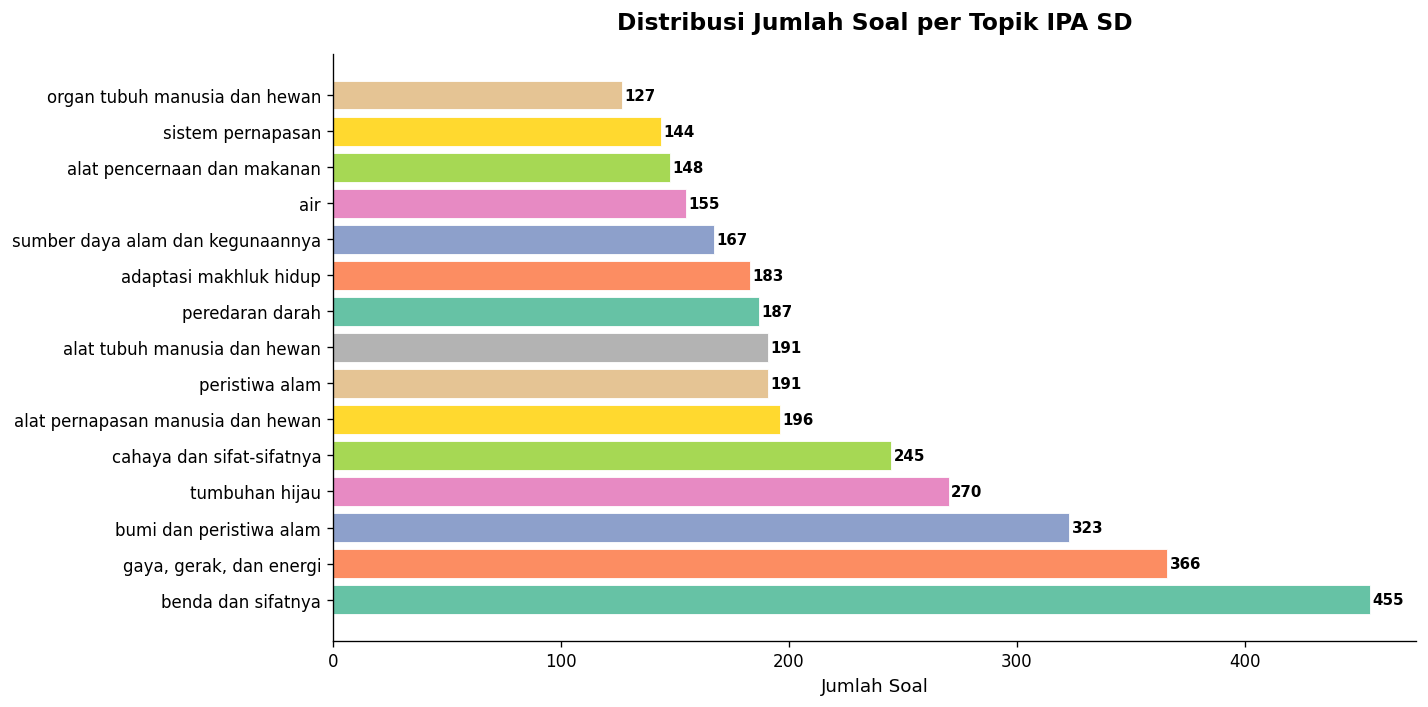

Insight: Topik terbanyak adalah benda dan sifatnya (455 soal)


In [15]:
# --- VISUALISASI 1: Distribusi Jumlah Soal per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

topic_count = df['topik'].value_counts()
colors = sns.color_palette('Set2', len(topic_count))

bars = ax.barh(topic_count.index, topic_count.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, topic_count.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('Distribusi Jumlah Soal per Topik IPA SD', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, topic_count.max() + 20)
plt.tight_layout()
plt.savefig('viz_01_distribusi_topik.png', bbox_inches='tight')
plt.show()
print('Insight: Topik terbanyak adalah', topic_count.idxmax(), f'({topic_count.max()} soal)')

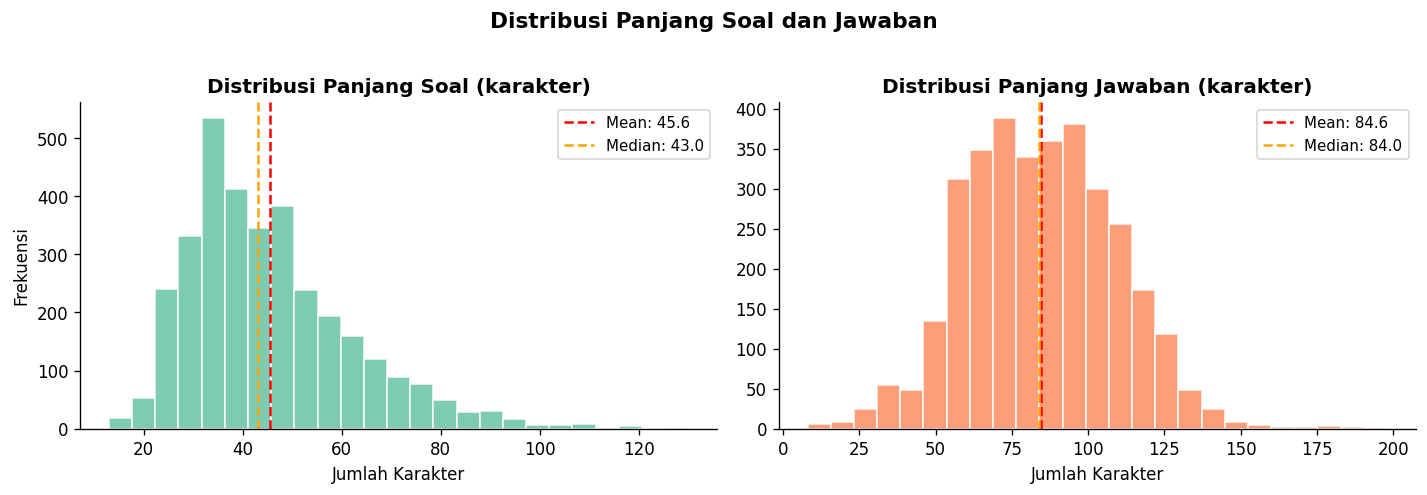

Insight: Rata-rata soal memiliki 46 karakter; rata-rata jawaban 85 karakter


In [16]:
# --- VISUALISASI 2: Distribusi Panjang Soal & Jawaban ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram panjang soal
axes[0].hist(df['panjang_soal'], bins=25, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(df['panjang_soal'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_soal"].mean():.1f}')
axes[0].axvline(df['panjang_soal'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_soal"].median():.1f}')
axes[0].set_title('Distribusi Panjang Soal (karakter)', fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Histogram panjang jawaban
axes[1].hist(df['panjang_jawaban'], bins=25, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[1].axvline(df['panjang_jawaban'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["panjang_jawaban"].mean():.1f}')
axes[1].axvline(df['panjang_jawaban'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {df["panjang_jawaban"].median():.1f}')
axes[1].set_title('Distribusi Panjang Jawaban (karakter)', fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].legend(fontsize=9)

fig.suptitle('Distribusi Panjang Soal dan Jawaban', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_distribusi_panjang.png', bbox_inches='tight')
plt.show()
print('Insight: Rata-rata soal memiliki', round(df['panjang_soal'].mean()), 'karakter;',
      'rata-rata jawaban', round(df['panjang_jawaban'].mean()), 'karakter')

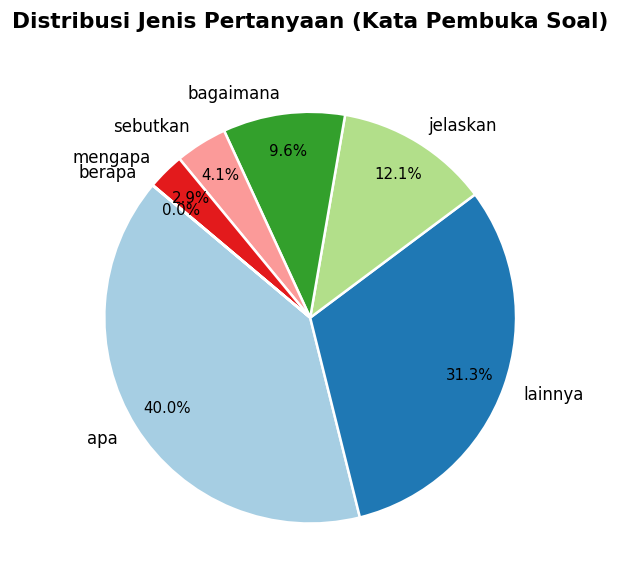

Insight: Pertanyaan terbanyak dimulai dengan kata: apa


In [17]:
# --- VISUALISASI 3: Jenis Pertanyaan ---
fig, ax = plt.subplots(figsize=(8, 5))

jenis_count = df['jenis_pertanyaan'].value_counts()
colors = sns.color_palette('Paired', len(jenis_count))

wedges, texts, autotexts = ax.pie(
    jenis_count.values,
    labels=jenis_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

for at in autotexts:
    at.set_fontsize(9)

ax.set_title('Distribusi Jenis Pertanyaan (Kata Pembuka Soal)',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz_03_jenis_pertanyaan.png', bbox_inches='tight')
plt.show()
print('Insight: Pertanyaan terbanyak dimulai dengan kata:', jenis_count.idxmax())

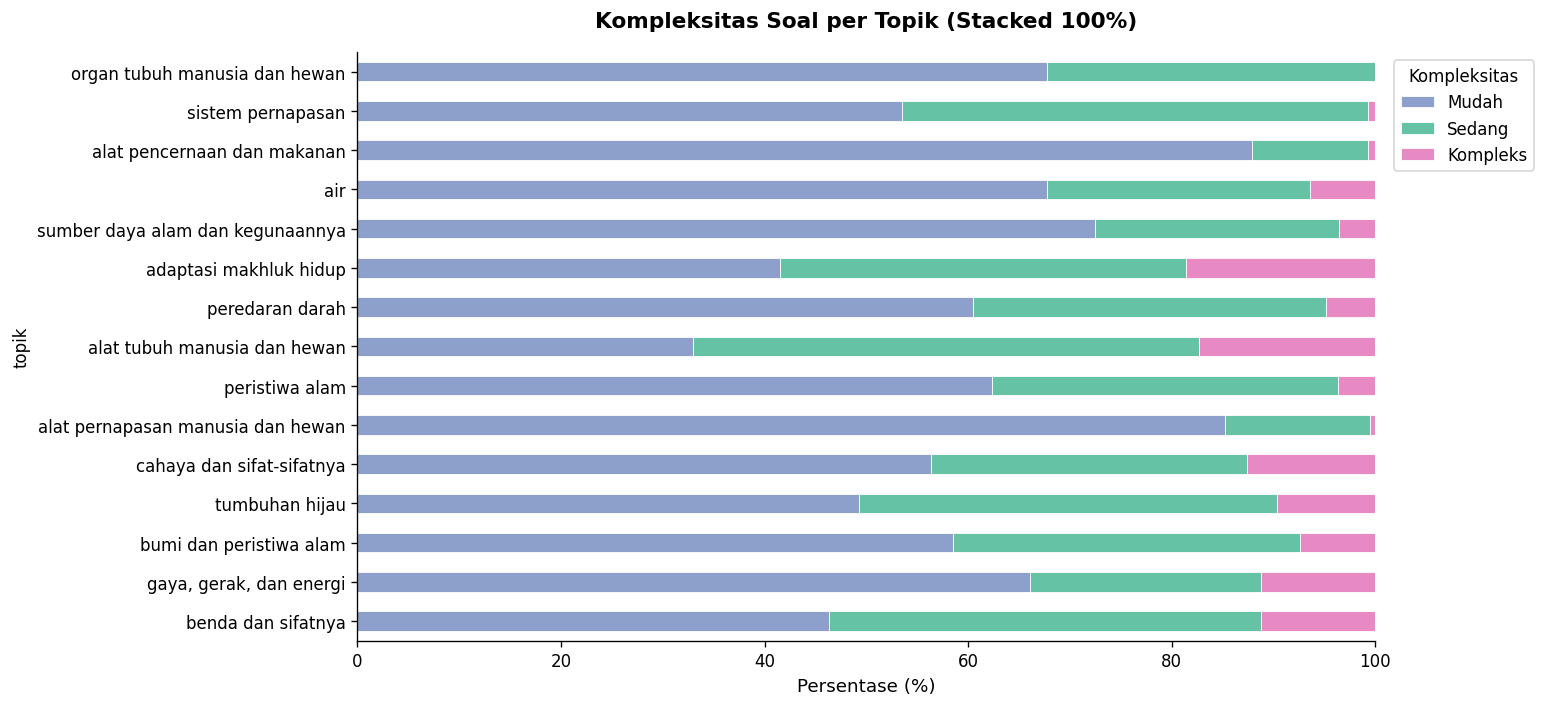

In [18]:
# --- VISUALISASI 4: Kompleksitas Soal per Topik ---
fig, ax = plt.subplots(figsize=(13, 6))

# Pivot table
pivot = df.groupby(['topik', 'kompleksitas']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['Mudah', 'Sedang', 'Kompleks'], fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Sort by total
pivot_pct = pivot_pct.loc[df['topik'].value_counts().index]

pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[PALETTE[2], PALETTE[0], PALETTE[3]],
               edgecolor='white', linewidth=0.5)

ax.set_xlabel('Persentase (%)', fontsize=11)
ax.set_title('Kompleksitas Soal per Topik (Stacked 100%)', fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Kompleksitas', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig('viz_04_kompleksitas_topik.png', bbox_inches='tight')
plt.show()

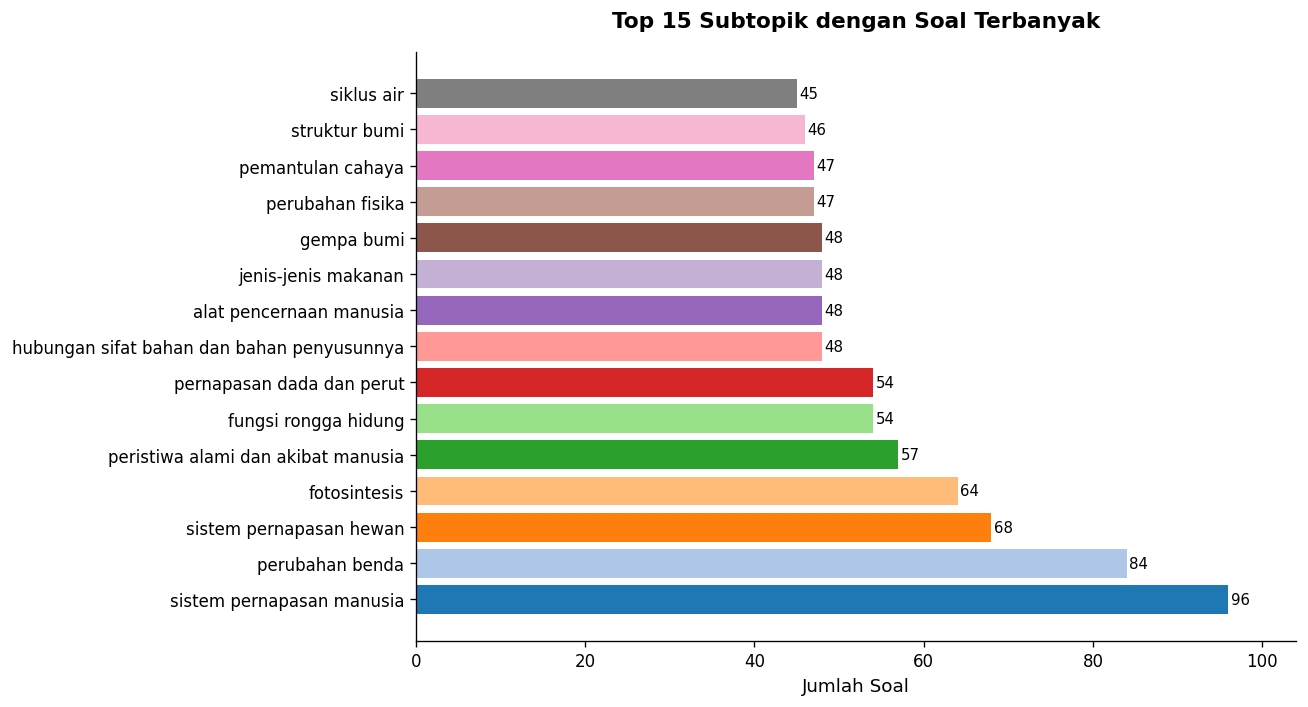

Insight: Subtopik terbanyak adalah: sistem pernapasan manusia (96 soal)


In [19]:
# --- VISUALISASI 5: Top 15 Subtopik ---
fig, ax = plt.subplots(figsize=(11, 6))

top15_subtopik = df['subtopik'].value_counts().head(15)
colors = sns.color_palette('tab20', 15)

bars = ax.barh(top15_subtopik.index, top15_subtopik.values, color=colors)
for bar, val in zip(bars, top15_subtopik.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=9)

ax.set_xlabel('Jumlah Soal', fontsize=11)
ax.set_title('Top 15 Subtopik dengan Soal Terbanyak', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top15_subtopik.max() + 8)
plt.tight_layout()
plt.savefig('viz_05_top_subtopik.png', bbox_inches='tight')
plt.show()
print('Insight: Subtopik terbanyak adalah:', top15_subtopik.idxmax(),
      f'({top15_subtopik.max()} soal)')

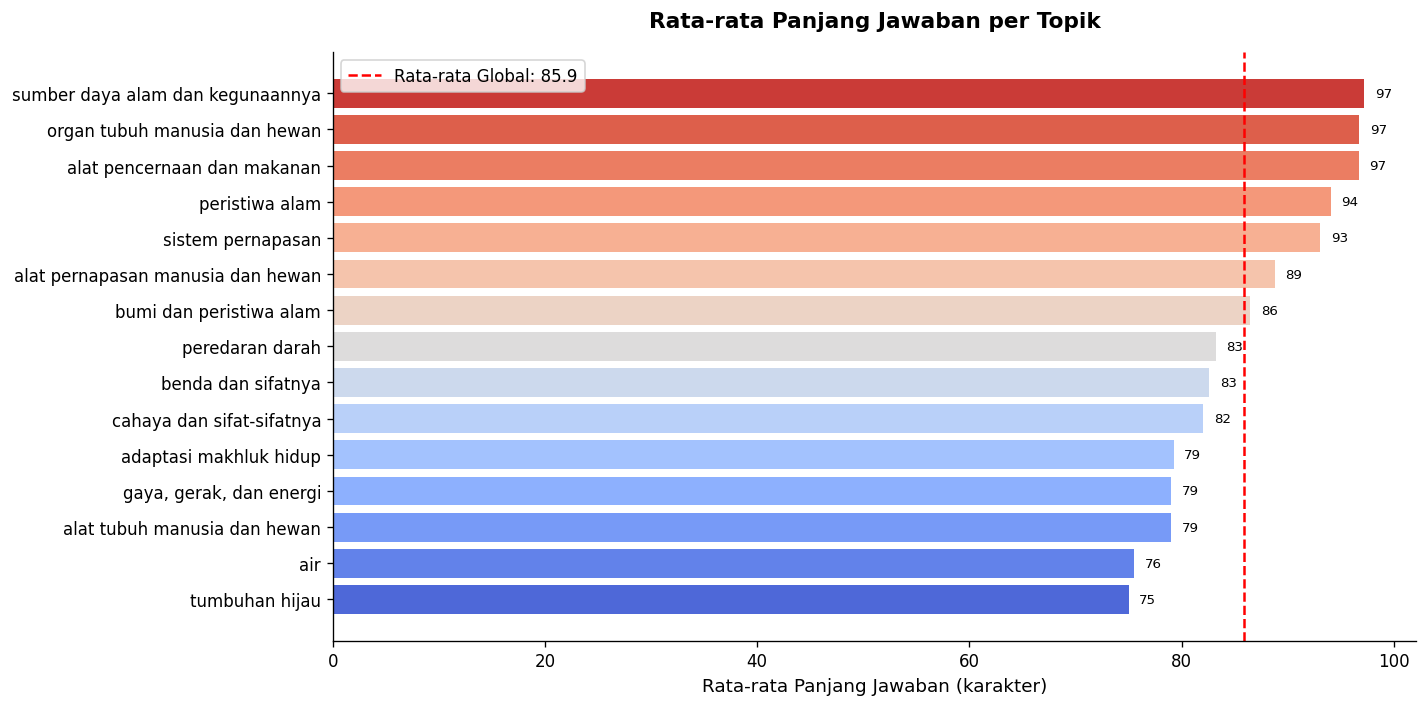

In [20]:
# --- VISUALISASI 6: Rata-rata Panjang Jawaban per Topik ---
fig, ax = plt.subplots(figsize=(12, 6))

avg_jawaban = df.groupby('topik')['panjang_jawaban'].mean().sort_values(ascending=True)
colors = sns.color_palette('coolwarm', len(avg_jawaban))

bars = ax.barh(avg_jawaban.index, avg_jawaban.values, color=colors)
ax.axvline(avg_jawaban.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata Global: {avg_jawaban.mean():.1f}')

for bar, val in zip(bars, avg_jawaban.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=8)

ax.set_xlabel('Rata-rata Panjang Jawaban (karakter)', fontsize=11)
ax.set_title('Rata-rata Panjang Jawaban per Topik', fontsize=13, fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('viz_06_avg_jawaban_topik.png', bbox_inches='tight')
plt.show()

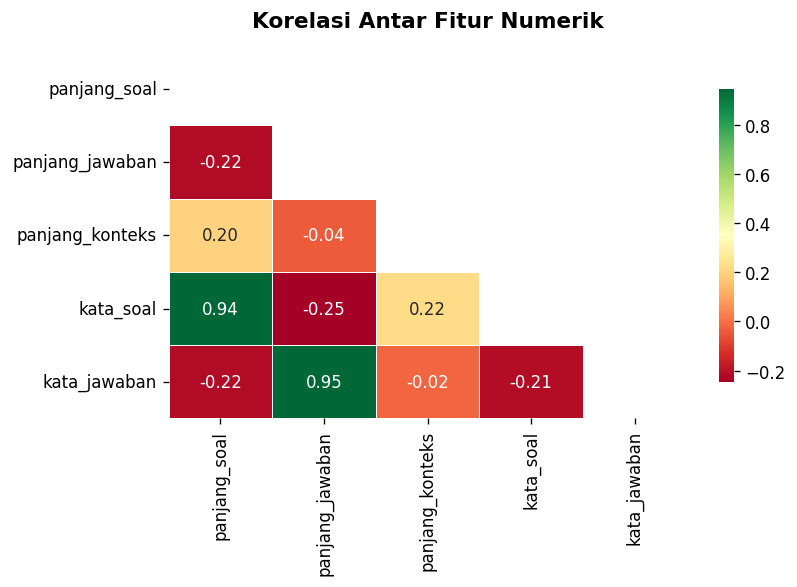

In [21]:
# --- VISUALISASI 7: Korelasi Fitur Numerik ---
fig, ax = plt.subplots(figsize=(7, 5))

num_cols = ['panjang_soal', 'panjang_jawaban', 'panjang_konteks',
            'kata_soal', 'kata_jawaban']
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Korelasi Antar Fitur Numerik', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_07_korelasi.png', bbox_inches='tight')
plt.show()

---
## Data Dictionary

In [22]:
data_dict = {
    'Kolom': ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks',
              'link_sumber', 'duplikat_soal', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks',
              'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas'],
    'Tipe': ['int', 'str', 'str', 'str', 'str', 'str', 'str',
             'str', 'bool', 'int', 'int', 'int', 'int', 'int', 'str', 'str'],
    'Deskripsi': [
        'Nomor urut soal (setelah reset)',
        'Topik utama IPA SD (sudah lowercase)',
        'Sub-topik yang lebih spesifik (sudah lowercase)',
        'Teks pertanyaan/soal',
        'Teks jawaban dari soal',
        'Contoh konkret untuk membantu pemahaman',
        'Kalimat latar belakang/konteks pertanyaan',
        'URL sumber buku ajar',
        'True jika teks kolom `soal` sama dengan salah satu baris di atasnya (occurrence pertama = False)',
        'Jumlah karakter pada kolom soal',
        'Jumlah karakter pada kolom jawaban',
        'Jumlah karakter pada kolom konteks',
        'Jumlah kata pada kolom soal',
        'Jumlah kata pada kolom jawaban',
        'Jenis pertanyaan berdasarkan kata pembuka soal',
        'Tingkat kompleksitas soal berdasarkan jumlah kata'
    ],
    'Contoh Nilai': [
        '1, 2, 3', 'alat tubuh manusia dan hewan', 'sistem pernapasan manusia',
        'sebutkan alat pernapasan pada manusia!', 'rongga hidung berfungsi...',
        'udara masuk melalui hidung...', 'manusia bernapas dengan...',
        'https://...', 'False / True', '47', '125', '60', '6', '15', 'sebutkan', 'Mudah'
    ]
}

dd_df = pd.DataFrame(data_dict)
print('DATA DICTIONARY')
dd_df

DATA DICTIONARY


,Kolom,Tipe,Deskripsi,Contoh Nilai
0,no,int,Nomor urut soal (setelah reset),"1, 2, 3"
1,topik,str,Topik utama IPA SD (sudah lowercase),alat tubuh manusia dan hewan
2,subtopik,str,Sub-topik yang lebih spesifik (sudah lowercase),sistem pernapasan manusia
3,soal,str,Teks pertanyaan/soal,sebutkan alat pernapasan pada manusia!
4,jawaban,str,Teks jawaban dari soal,rongga hidung berfungsi...
5,contoh,str,Contoh konkret untuk membantu pemahaman,udara masuk melalui hidung...
6,konteks,str,Kalimat latar belakang/konteks pertanyaan,manusia bernapas dengan...
7,link_sumber,str,URL sumber buku ajar,https://...
8,duplikat_soal,bool,True jika teks kolom `soal` sama dengan salah ...,False / True
9,panjang_soal,int,Jumlah karakter pada kolom soal,47


---
## Export Data Bersih

In [23]:
# Export clean dataset
EXPORT_PATH = '../data_cleran/datasoal_clean.csv'
df.to_csv(EXPORT_PATH, index=False)

print('Data bersih berhasil disimpan!')
print(f'Path  : {EXPORT_PATH}')
print(f'Shape : {df.shape}')
print(f'Kolom : {df.columns.tolist()}')

Data bersih berhasil disimpan!
Path  : ../data_cleran/datasoal_clean.csv
Shape : (3348, 15)
Kolom : ['no', 'topik', 'subtopik', 'soal', 'jawaban', 'contoh', 'konteks', 'link_sumber', 'panjang_soal', 'panjang_jawaban', 'panjang_konteks', 'kata_soal', 'kata_jawaban', 'jenis_pertanyaan', 'kompleksitas']


---
## Ringkasan Temuan (Summary of Insights)

| # | Insight | Detail |
|---|---------|--------|
| 1 | **Inkonsistensi Topik** | 29 nilai unik topik → 16 topik unik setelah normalisasi (duplikat kapitalisasi) |
| 2 | **Soal Duplikat** | Baris dengan teks soal sama ditandai `duplikat_soal`; semua baris tetap ada untuk dashboard & audit |
| 3 | **Topik Terbanyak** | `alat tubuh manusia dan hewan` (131 soal) & `benda dan sifatnya` (gabungan ~200+) |
| 4 | **Panjang Soal** | Rata-rata 50 karakter (7–8 kata), distribusi normal |
| 5 | **Panjang Jawaban** | Rata-rata 99 karakter, distribusi right-skewed (ada jawaban sangat panjang) |
| 6 | **Jenis Pertanyaan** | Dominasi `sebutkan` dan `apa` — cocok untuk Q&A chatbot |
| 7 | **Kompleksitas** | Mayoritas soal tergolong `Sedang` (6–10 kata) |
| 8 | **Kesiapan Model** | Data siap digunakan sebagai input training NLP chatbot |

---
*Notebook selesai — Lanjutkan ke `dashboard.py` untuk visualisasi interaktif Streamlit.*